<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Volatility-Visualization-and-Autocorrelation-of-Returns-and-Squared-Returns/Volatility_Visualization_and_Autocorrelation_of_Returns_and_Squared_Returns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.graphics.tsaplots as tsaplots

In [ ]:
tickers = ['^GSPC']

data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')['Close']
returns = data.pct_change().dropna()

returns.head()

/tmp/ipython-input-382636947.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2015-01-05,-0.018278
2015-01-06,-0.008893
2015-01-07,0.011630
2015-01-08,0.017888
2015-01-09,-0.008404


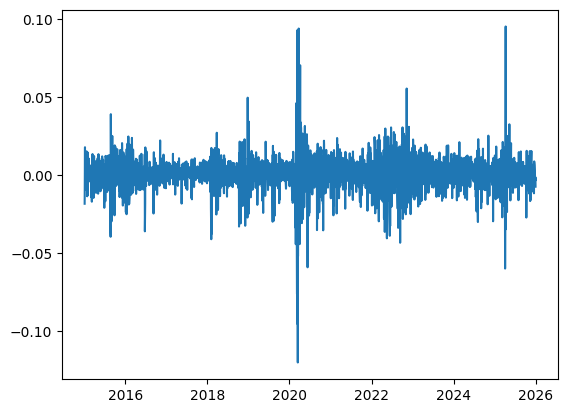

In [ ]:
plt.plot(returns.index, returns)
plt.show()

Mandelbrot's Observation (Look for)

In [ ]:
squared_returns = returns**2
squared_returns.head()

Ticker,^GSPC
Date,
2015-01-05,0.000334
2015-01-06,0.000079
2015-01-07,0.000135
2015-01-08,0.000320
2015-01-09,0.000071


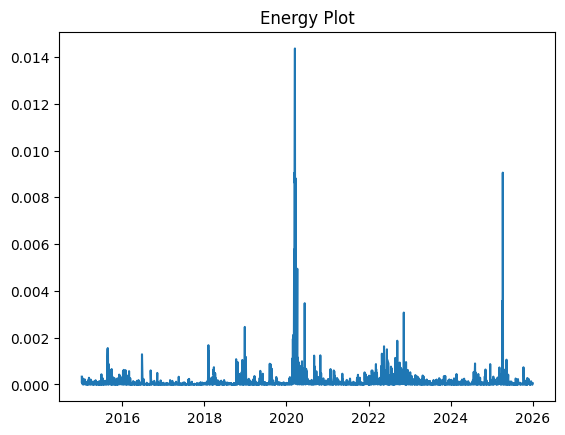

In [ ]:
plt.title('Energy Plot')
plt.plot(squared_returns.index, squared_returns)
plt.show()

Memory Test (Autocorrelation)

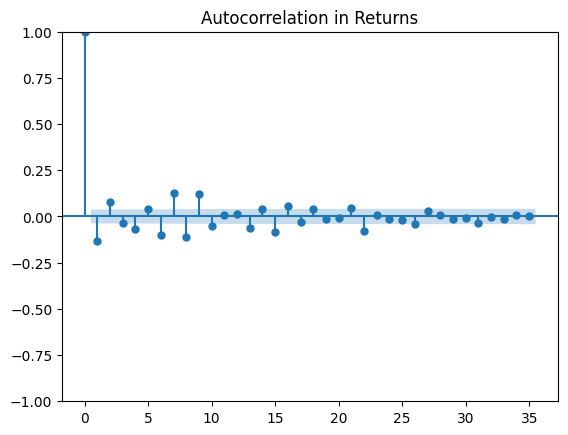

In [ ]:
tsaplots.plot_acf(returns,
                  title = 'Autocorrelation in Returns');

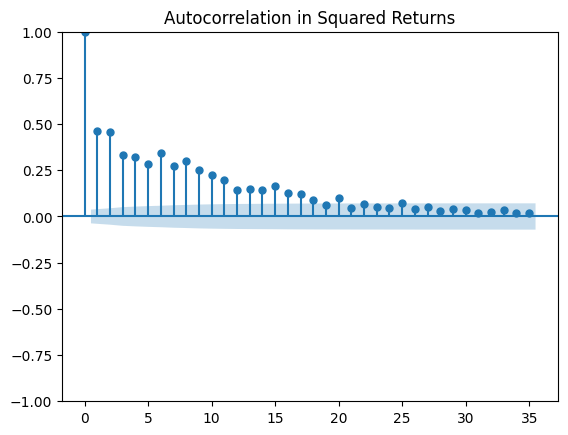

In [ ]:
tsaplots.plot_acf(squared_returns,
                  title = 'Autocorrelation in Squared Returns');

Observation,Market Meaning
1. All bars inside blue area,"Random Walk: The market has fully ""priced in"" the news. No predictable pattern exists."
2. Strong Positive Lag 1,"Momentum: If the stock went up yesterday, it's likely to go up today (Under-reaction to news)."
3. Strong Negative Lag 1,"Mean Reversion: A ""bounce"" or ""correction."" If it went up yesterday, it's likely to pull back today (Over-reaction)."
4. "Spikes at Lag 5, 10, etc.",Seasonality: There is a weekly or bi-weekly pattern (common in high-frequency trading or institutional rebalancing).

# **The Autocorrelation Plots imply that the market is efficient to long-term returns. Prices beyond 15-20 days away from today don't have impact on today's price.**

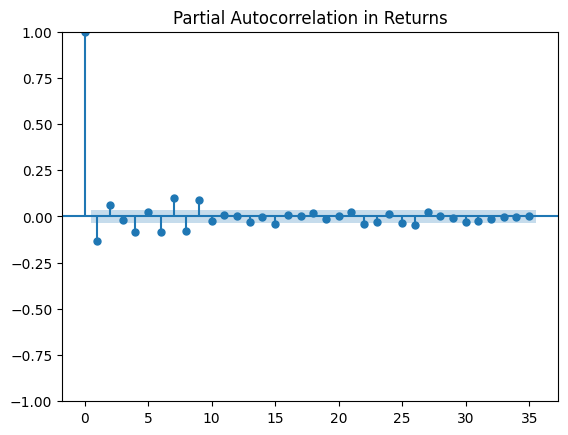

In [ ]:
tsaplots.plot_pacf(returns,
                  title = 'Partial Autocorrelation in Returns');

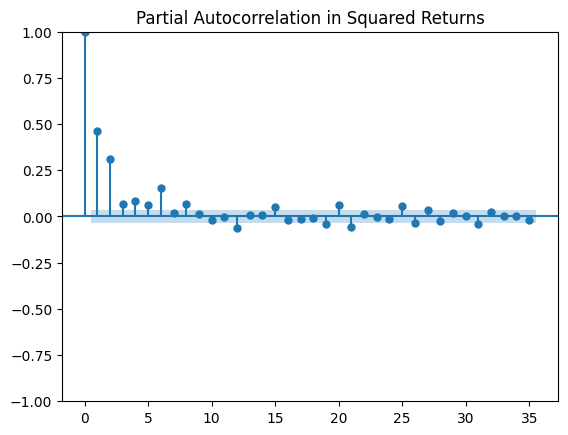

In [ ]:
tsaplots.plot_pacf(squared_returns,
                  title = 'Partial Autocorrelation in Squared Returns');